# Graficos do Merge Sort em Python

Este notebook mostra os resultados medidos da implementacao em Python.

A ideia e comparar os tres cenarios do projeto:
- Melhor Caso
- Caso Medio
- Pior Caso

Como os tempos de `n = 1.000`, `n = 10.000` e `n = 100.000` sao bem diferentes, o eixo Y sera exibido em escala logaritmica para facilitar a leitura.

## 1. Importacoes

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Caminhos e configuracao visual

Nesta etapa definimos os caminhos do projeto, os nomes amigaveis dos cenarios e uma configuracao visual simples para os graficos.

In [2]:
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

ROOT = Path('..').resolve()
RESULTS_DIR = ROOT / 'results'
GRAPHS_DIR = ROOT / 'graphs'
GRAPHS_DIR.mkdir(exist_ok=True)

TAMANHO_ORDEM = ['pequeno', 'medio', 'grande']
CENARIO_ORDEM = ['melhor_caso', 'caso_medio', 'pior_caso']

ROTULOS_CENARIO = {
    'melhor_caso': 'Melhor Caso',
    'caso_medio': 'Caso Medio',
    'pior_caso': 'Pior Caso',
}

CORES_CENARIO = {
    'melhor_caso': '#2E86AB',
    'caso_medio': '#F18F01',
    'pior_caso': '#C73E1D',
}

## 3. Leitura dos dados

Aqui lemos o arquivo CSV gerado pelo benchmark em Python e organizamos os tamanhos na ordem `pequeno -> medio -> grande`.

In [3]:
# Le o arquivo de resultados gerado pelo benchmark em Python.
df_python = pd.read_csv(RESULTS_DIR / 'python_results.csv')

# Define a ordem correta dos tamanhos para manter o grafico consistente.
df_python['tamanho'] = pd.Categorical(df_python['tamanho'], categories=TAMANHO_ORDEM, ordered=True)
df_python = df_python.sort_values(['tamanho', 'cenario']).reset_index(drop=True)

In [4]:
df_python

,linguagem,cenario,tamanho,n,media_ms,desvio_ms,min_ms,max_ms,rodadas
0,Python,caso_medio,pequeno,1000,2.2060,0.5197,1.9564,4.0662,30
1,Python,melhor_caso,pequeno,1000,2.2306,0.4495,1.6777,3.3689,30
2,Python,pior_caso,pequeno,1000,1.9848,0.4835,1.7001,3.5191,30
3,Python,caso_medio,medio,10000,25.7639,1.2348,24.1190,29.7981,30
4,Python,melhor_caso,medio,10000,22.0892,3.4251,19.6827,33.3268,30
5,Python,pior_caso,medio,10000,21.2625,1.3615,20.0802,25.8447,30
6,Python,caso_medio,grande,100000,349.5182,30.4268,313.1663,409.8776,30
7,Python,melhor_caso,grande,100000,267.1731,16.7301,242.6445,309.8046,30
8,Python,pior_caso,grande,100000,255.7053,4.9912,247.7212,268.0577,30


## 4. Preparacao dos dados

Agora transformamos a tabela para deixar os tres cenarios lado a lado em cada tamanho de entrada.

Tambem criamos rotulos mais claros para o eixo X:
- Pequeno (1000)
- Medio (10000)
- Grande (100000)

In [5]:
# Monta uma tabela em que cada coluna representa um cenario.
tabela_python = (
    df_python.pivot(index='tamanho', columns='cenario', values='media_ms')
    .reindex(TAMANHO_ORDEM)
    .reindex(columns=CENARIO_ORDEM)
)

# Busca o valor real de n para exibir junto ao nome do tamanho.
n_por_tamanho = (
    df_python[['tamanho', 'n']]
    .drop_duplicates()
    .set_index('tamanho')['n']
    .to_dict()
)

rotulos_tamanho = [
    f"Pequeno ({n_por_tamanho['pequeno']})",
    f"Medio ({n_por_tamanho['medio']})",
    f"Grande ({n_por_tamanho['grande']})",
]

tabela_python

cenario,melhor_caso,caso_medio,pior_caso
tamanho,,,
pequeno,2.2306,2.2060,1.9848
medio,22.0892,25.7639,21.2625
grande,267.1731,349.5182,255.7053


## 5. Grafico principal

Neste grafico, comparamos o tempo medio de execucao do Merge Sort em Python nos cenarios de Melhor Caso, Caso Medio e Pior Caso.

- Eixo X: mostra o tamanho da entrada testada e, entre parenteses, o valor de `n` usado em cada grupo.
- Eixo Y: mostra o tempo medio de execucao em milissegundos.
- Foi usada escala logaritmica no eixo Y porque os tempos do caso grande sao muito maiores do que os do caso pequeno e medio.
- Marcas como `10^0`, `10^1`, `10^2` e `10^3` representam potencias de 10 em milissegundos. Isso significa, por exemplo, que sair de `10^1` para `10^2` indica um aumento de 10 para 100 ms.
- A leitura principal e observar que o tempo cresce com o aumento de `n` e que os tres cenarios permanecem relativamente proximos, o que e coerente com o comportamento esperado do Merge Sort.

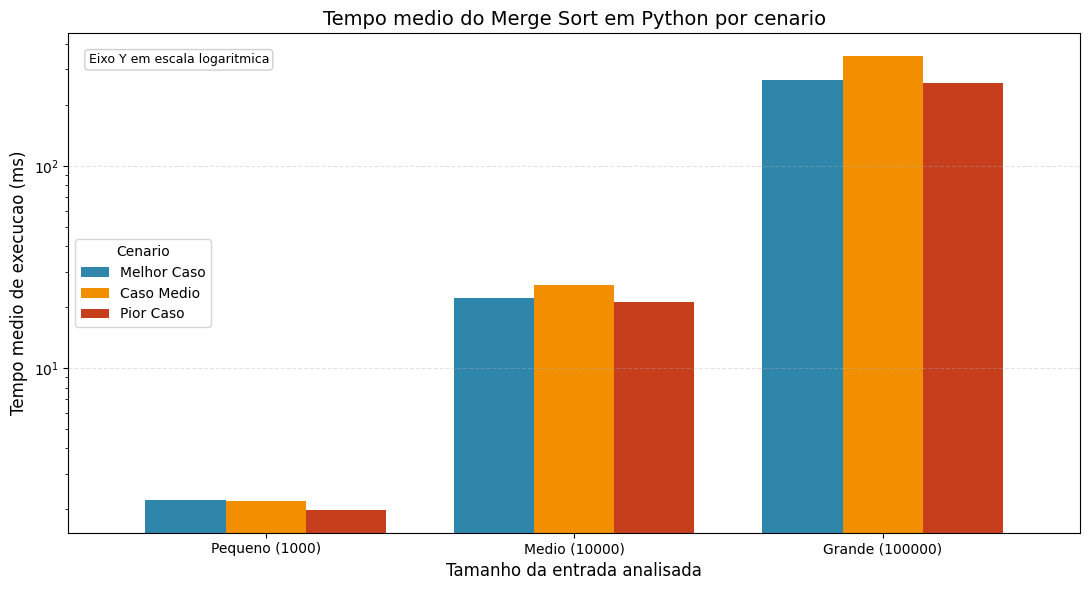

In [6]:
# Cria o grafico de barras agrupadas com cores fixas por cenario.
ax = tabela_python.plot(
    kind='bar',
    color=[CORES_CENARIO[cenario] for cenario in CENARIO_ORDEM],
    width=0.74,
)

# Ajusta titulo, eixos e legenda para deixar a leitura mais direta.
ax.set_title('Tempo medio de execucao do Merge Sort em Python nos tres cenarios')
ax.set_xlabel('Tamanho da entrada analisada')
ax.set_ylabel('Tempo medio de execucao (ms)')
ax.set_xticklabels(rotulos_tamanho, rotation=0)
ax.set_yscale('log')
ax.legend([ROTULOS_CENARIO[cenario] for cenario in CENARIO_ORDEM], title='Cenario')

# Adiciona grade leve e duas notas curtas para orientar a leitura.
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.text(
    0.02,
    0.96,
    'Eixo Y em escala logaritmica',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)
ax.text(
    0.98,
    0.96,
    'Media de 30 execucoes por caso',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'python_cenarios.png', dpi=200)
plt.show()
plt.close()